In [2]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from PIL import Image

train_dir = "/content/drive/MyDrive/dataset/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/dataset/Copy of devnagari digit/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical
def load_images(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            img = Image.open(img_path).convert('L')
            img = img.resize((img_width, img_height))
            img_array = (np.array(img) / 255.0).astype('float32')

            images.append(img_array)
            labels.append(label)
    return np.array(images), np.array(labels)

# Load data
X_train_raw, y_train_raw = load_images(train_dir)
X_test_raw, y_test_raw = load_images(test_dir)

indices = np.arange(X_train_raw.shape[0])
np.random.shuffle(indices)
X_train_raw = X_train_raw[indices]
y_train_raw = y_train_raw[indices]

x_train = X_train_raw.reshape(-1, img_height, img_width, 1)
x_test = X_test_raw.reshape(-1, img_height, img_width, 1)

y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

Training data shape: (17004, 28, 28, 1)
Training labels shape: (17004, 10)


##Build Model

In [4]:
model = Sequential([
    Flatten(input_shape=(img_height, img_width, 1)),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

##Model Compilation and training

In [5]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    # Using .keras extension as .h5 is legacy
    ModelCheckpoint("best_devnagari_model.keras", save_best_only=True),
    EarlyStopping(monitor='val_loss', patience=3)
]

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8494 - loss: 0.5194 - val_accuracy: 0.9447 - val_loss: 0.1971
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9580 - loss: 0.1407 - val_accuracy: 0.9568 - val_loss: 0.1456
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9696 - loss: 0.1021 - val_accuracy: 0.9691 - val_loss: 0.1063
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9775 - loss: 0.0738 - val_accuracy: 0.9747 - val_loss: 0.0922
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9834 - loss: 0.0552 - val_accuracy: 0.9774 - val_loss: 0.0775
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9889 - loss: 0.0388 - val_accuracy: 0.9738 - val_loss: 0.0846
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9901 - loss: 0.0339 - val_accuracy: 0.9794 - val_loss: 0.0772
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9888 - loss: 0.0363 - val_accuracy: 0.

##Evaluation and Prediction

In [6]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

predictions = model.predict(x_test)
predicted_label = np.argmax(predictions[0])
true_label = np.argmax(y_test[0])

print("Predicted labels:", predicted_label)
print("True labels:", true_label)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9663 - loss: 0.1341
Test Accuracy: 96.63%
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted labels: 0
True labels: 0


##Save and Load Model

In [7]:
model.save("devnagari_model.keras")

loaded_model = tf.keras.models.load_model("devnagari_model.keras", compile=False)

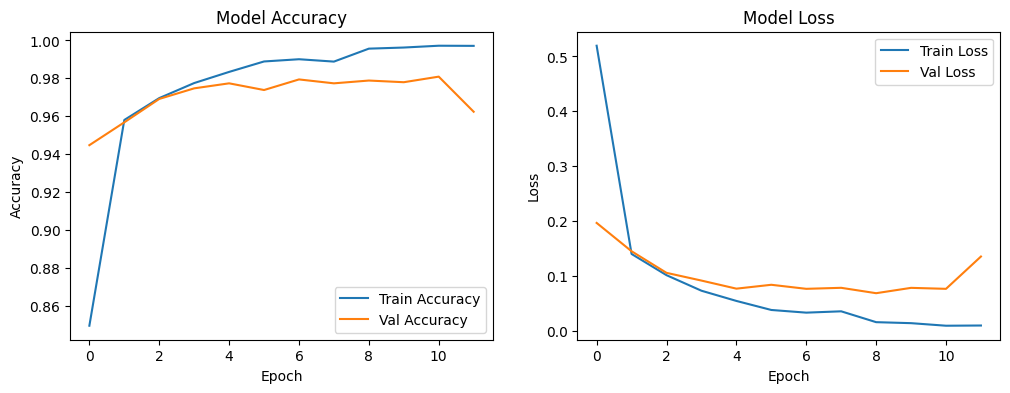

In [9]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(12, 4))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

plot_history(history)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


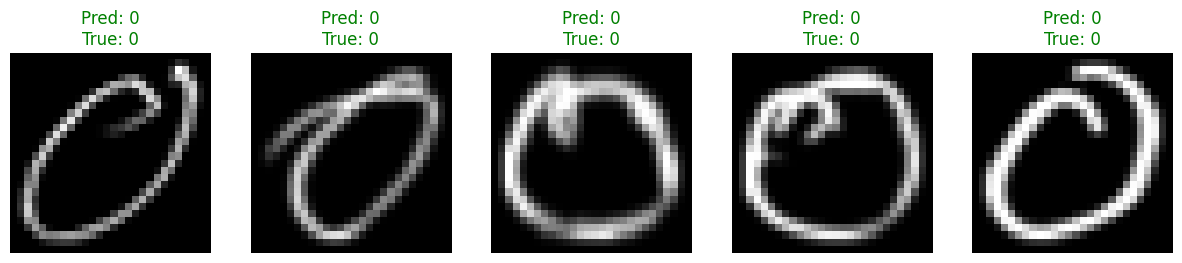

In [10]:
def visualize_predictions(x_test, y_test, model, count=5):
    plt.figure(figsize=(15, 5))
    predictions = model.predict(x_test[:count])

    for i in range(count):
        plt.subplot(1, count, i + 1)

        plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

        pred_label = np.argmax(predictions[i])
        true_label = np.argmax(y_test[i])

        color = 'green' if pred_label == true_label else 'red'
        plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
        plt.axis('off')

    plt.show()

visualize_predictions(x_test, y_test, model)